# Higher-order character decomposition: ``char`` module

> **NOTE:** This tutorial assumes familiarity with the concepts explained in  [Conceptual and mathematical background of higher-order Fourier analysis](concept-background) and that the ``HoFa`` package has already been installed, see [Installation](../getting_started/installation).

In this notebook we are going to learn how the ``HoFa`` package identifies higher-order components of a function.

## What are higher-order characters?

As we saw in [Conceptual and mathematical background of higher-order Fourier analysis](conceptual_background), the question of _what are the higher-order components of a function_ is a subtle one, especially because, once we go beyond classical Fourier analysis, we lose the concept of **exactness** and replace it with the concepts of **sparsity** and **efficiency**.

This was illustrated in the quadratic setting where we saw that, when working with the Gowers $U^3$-norm, the family of classical Fourier characters such as

$$ x\mapsto \exp(2 \pi i x \xi)$$

needs to be enlarged to include, among what we expect to call *quadratic characters*, functions such as quadratic waves of the form

$$ x\mapsto  \exp(2 \pi i (x^2 \xi+\eta x)).$$

This already shows that quadratic characters are too numerous to form a basis of our vector space of functions. This is one sense in which we have the above-mentioned loss of exactness (we lose the concept of a basis, and its associated ability to give _exact_ decompositions of functions as linear combinations of basis elements).

Moreover, it is known (as we discuss in [Theoretical foundations and extensions](theoretical_foundations_extensions)) that quadratic characters must also include functions that can be more subtle than these quadratic waves, such as _2-step nilsequences_.

Nevertheless, there is a relatively simple and natural notion of _quadratic character_ (or, more generally, of $(k-1)$-th *order character*, if we work with the $U^{k+1}$-norm), which happens to capture all these examples. We discussed these quadratic characters in [the U3-norm case in the Conceptual background](concept-background-u3-case), and saw that they are defined by the  property that their multiplicative derivatives should be _structured functions_ in the classical Fourier sense, namely, they should be well-approximated by linear combinations of a few classical Fourier characters. This notion generalizes also naturally to higher orders, leading to the idea of a _character of order_ $k$ being a function whose multiplicative derivatives are _structured functions_ of order $k-1$.

### The general goal: find the dominant higher-order characters of a function

Recent theoretical results indicate that functions on finite abelian groups can be decomposed, up to error terms that are small in either the Euclidean norm or the Gowers $U^{k+1}$-norm, by sums of a few order-$k$  characters (see [Theoretical foundations and extensions](theoretical_foundations_extensions)).

The purpose of this tutorial is to explore how the ``HoFa`` package can **compute such decompositions** of a function $f$, namely decompositions of the form $f=f_e+\sum g_i$ where $f_e$ is an _error term_ and the $g_i$ are characters of order $k$. We shall focus on the quadratic case.

Similarly as for the ``hofa.rgz.regularize`` method, these decompositions depend on tunable parameters. While the package includes default heuristics for selecting these parameters, practitioners are encouraged to experiment with different strategies for their specific applications.

> **REMARK.** Recall that the [Discrete Fourier Transform](https://en.wikipedia.org/wiki/Discrete_Fourier_transform) gives a **unique** decomposition for functions on (say) $\mathbb{Z}/n\mathbb{Z}$. In particular, any _higher-order Fourier character_ can be decomposed uniquely as some linear combination of Fourier characters. However, in general, this decomposition is not **sparse** or **efficient**. Thus,  decompositions into a few higher-order characters can often be much sparser than classical Fourier decompositions.

## A simple example: identifying a single quadratic character

Let us begin by importing the necessary libraries. Recall that we are assuming that the ``HoFa`` package is already installed, see [Installation](../getting_started/installation). For a quick installation, run the following command:

```console
(hofavenv) $ pip install hofa
```

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=5)

import hofa.char as char
import hofa.rgz as rgz
import hofa.cdf as cdf

Consider a single quadratic character $g(x):=e^{2\pi i x^2/n}$, for $x=0,\ldots,n-1$. As usual, suppose that we perturb it with some random noise $f_r(x)\sim \text{Unif}[-1,1)$ in a way that we can only see the convex combination $f:=tf_r+(1-t)g$ for $t=0.4$.

In [2]:
n = 101
t = 0.4

rng = np.random.default_rng(seed=123)

x = np.arange(n)
g = np.exp(2*1j*np.pi*x**2/n)

f = rng.uniform(-1, 1, size=len(x))*t+(1-t)*g

The ``hofa.char`` module contains a method ``spechoft`` (Spectral higher-order Fourier transform) which enables us to recover the underlying structured component $(1-t)g$. It returns data related to finding those characters, but the most important part is the attribute ``higher_order_char``, which is a ``numpy.ndarray`` of shape ``(f.shape,m)`` where ``m`` represents the number of components (higher-order characters) found.

If we represent the ``higher_order_char`` result of ``spechoft`` as a family of vectors $v_i$, the resulting higher-order character decomposition of $f$ is as follows:

$$ f = f_e+\sum_i \langle f,v_i\rangle v_i, \text{ where } f_e \text{ is the error term.}$$

> **NOTE**: Recall that the default use of ``spechoft`` utilizes some heuristics for some tunable parameters. We will learn below how to modify these parameters and obtain different decompositions for the same function.

In our case, since we know that the function $f$ in our example will contain exactly one higher-order character, we simply define ``v`` below as such an element.

In [3]:
v = char.spechoft(f, rng=123).higher_order_char[...,0]

coeff_proj = np.mean(f*v.conjugate())

error = np.mean(np.abs(g*(1-t)-coeff_proj*v))
print(r'L1 error between the known quadratic Fourier character (1-t)g and <f,v>v : '+str(error))

L1 error between the known quadratic Fourier character (1-t)g and <f,v>v : 0.02255730958724428


As we can see, the error is very small and, up to the scaling factor $(1-t)$, we are able to recover the character $g$.

Let us plot below the (real part of the) original function $(1-t)g$, the (real part of the) noisy version $f$, and the (real part of the) reconstruction which comes from the projection of $f$ to the (sole) eigenvector returned by ``spechoft``.

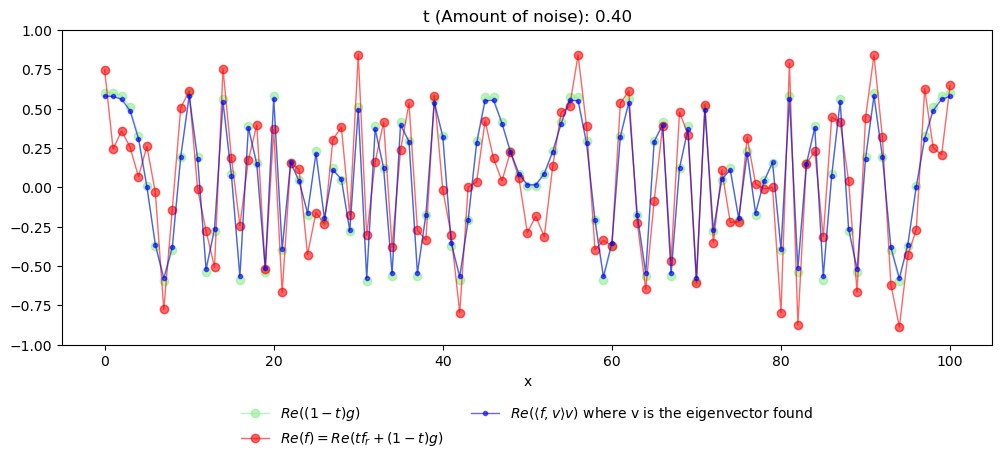

In [4]:
fig, ax = plt.subplots(figsize=(12, 5))

# Plot original (1-t)*f_s in light green
ax.plot(x, np.real(g*(1-t)), linestyle='-', color='lightgreen', marker='o', markersize=6, linewidth=1, alpha=0.6, label=r'$Re((1-t)g)$')

# Plot modified function in red
ax.plot(x, np.real(f), linestyle='-', color='red', marker='o', markersize=6, linewidth=1, alpha=0.6, label=r'$Re(f) = Re(tf_r+(1-t)g)$')

# Plot recovered function in blue
ax.plot(x, np.real(coeff_proj*v), linestyle='-', color='blue', marker='o', markersize=3, linewidth=1, alpha=0.6, label=r'$Re(\langle f,v\rangle v)$ where v is the eigenvector found')

# Customize the plot
ax.set_xlabel("x")
ax.set_title(f"t (Amount of noise): {t:.2f}")
ax.set_ylim(-1,1)

# Legend below the plot
fig.subplots_adjust(bottom=0.25)  # Adjust layout to fit legend below
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2, frameon=False)

# Show the plot
plt.show()

This first example may not seem very impressive since, after all, we already know a method from the ``hofa`` package that can recover the original character, namely ``hofa.rgz.regularize`` (indeed this method recovers this _single_ character simply as the regularized version of the function $f$).

The real challenge begins when there are _several_ higher-order  characters that cannot be distinguished by simply applying ``hofa.rgz.regularize``. The next example illustrates a method from ``hofa.char`` which achieves this distinction.

## A first multi-character example

Let $g(x):=\sin(2\pi x^2/n)$ and, as above, let $f_r(x)\sim \text{Unif}[-1,1)$. Again, assume that we are presented with a noisy version $f:=tf_r+(1-t)g$ for some $t\in[0,1)$.

Returning to our intuition with quadratic Fourier characters, it is reasonable to aim to decompose $g$ as follows:

$$ g(x) = \sin(2\pi x^2/n) = \frac{\exp(2\pi i x^2/n)-\exp(-2\pi i x^2/n)}{2i}. $$

Equivalently, the quadratic characters hidden in $f$ that we want to extract are $(1-t)\exp(2\pi i x^2/n)/2i$ and $-(1-t)\exp(-2\pi i x^2/n)/2i$.

In [5]:
n = 1501
t = 0.3

x = np.arange(n)
g = np.sin(2*np.pi*x**2/n)

# We fix a seed for reproducibility
rng = np.random.default_rng(seed=28)
f = rng.uniform(-1, 1, size=len(x))*t+(1-t)*g

The method ``char.spechoft`` is specifically designed to **identify and extract** such components.

In [6]:
# As usual, we fix an rng for reproducibility
rnd_sep_result = char.spechoft(f, rng=28)

eichars = rnd_sep_result.higher_order_char

The attribute ``higher_order_char`` contains an array of the quadratic Fourier characters that compose the structured part of $f$, i.e., $(1-t)g$. In this example (try it in your notebook!), you will find exactly two characters, which correspond to the two quadratic Fourier characters that make up $g$.

Below, we visualize the key elements of this example. For clarity, we first plot the real-valued functions $f$ and $(1-t)g$. For the quadratic Fourier characters and the extracted quadratic components, we plot both their **real and imaginary parts**.

Note that, similarly to what happens with the standard Fourier transform (which uses complex exponentials as Fourier characters), here even if the function to decompose is real-valued (e.g., $f$ or $(1-t)g$), its decomposition may still involve **complex numbers**.

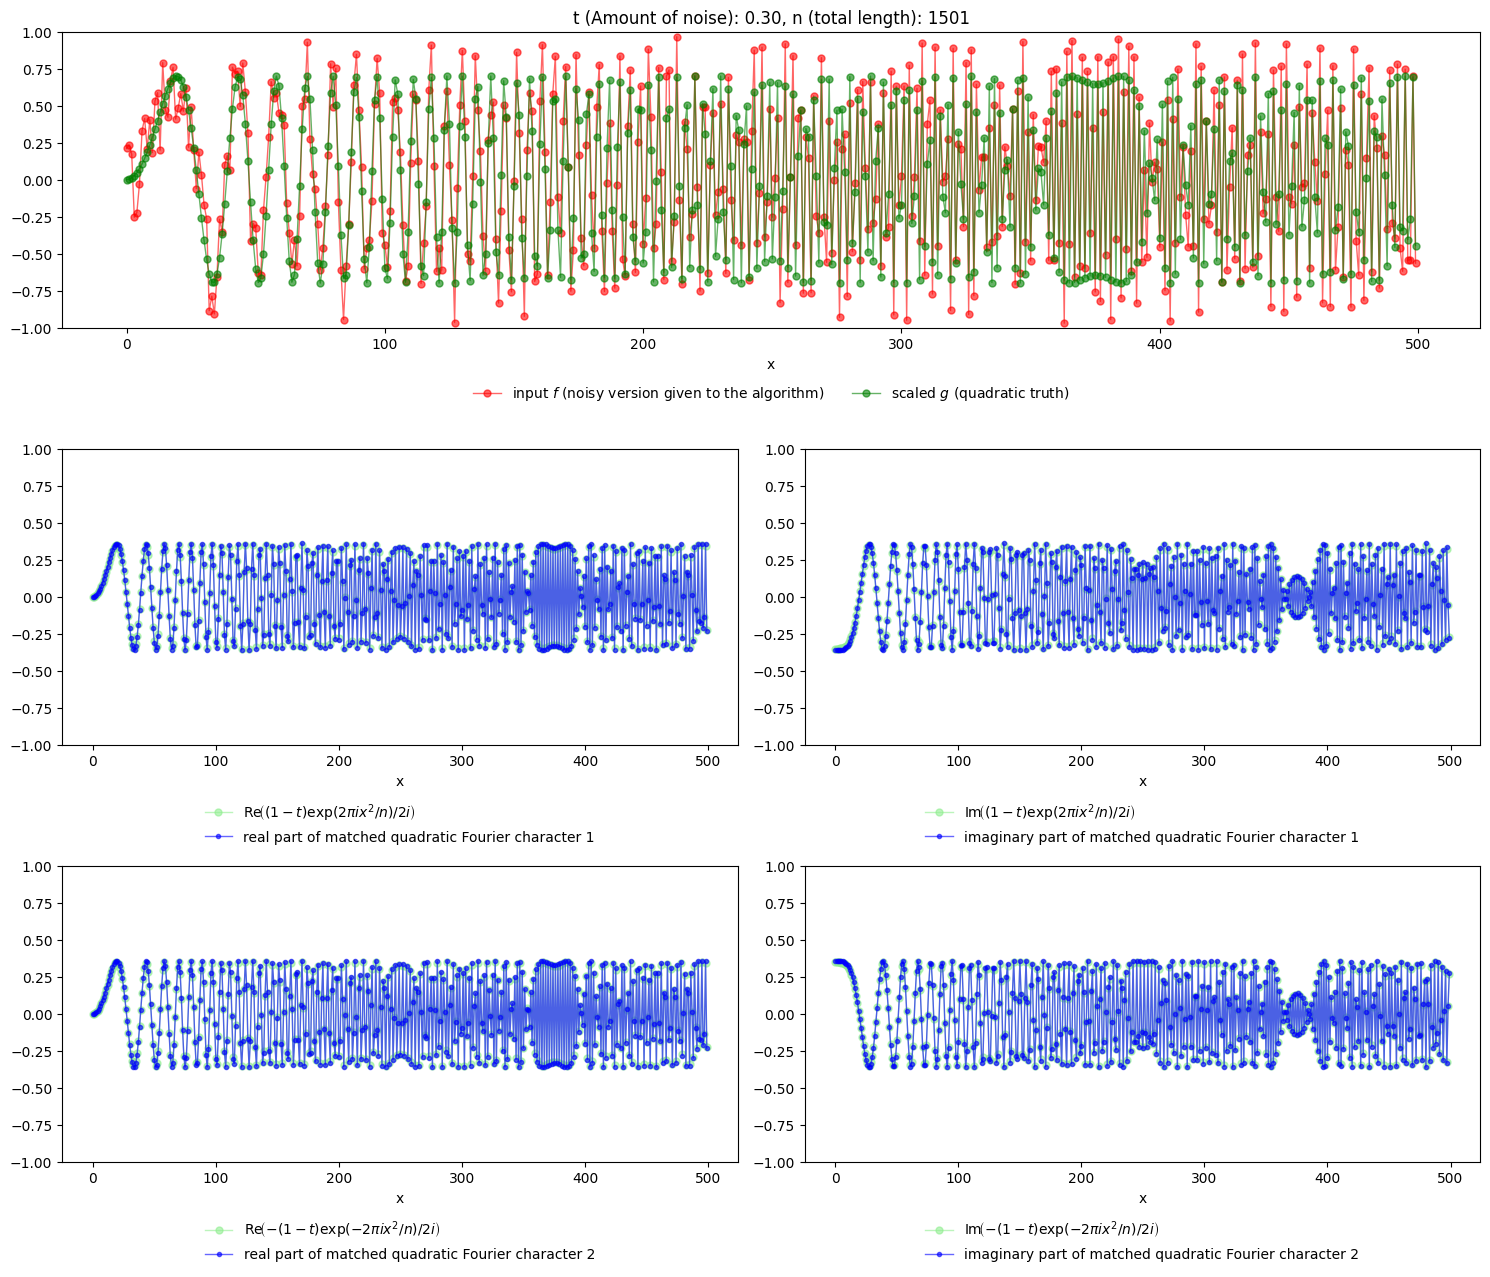

In [7]:
import itertools
import numpy as np
import matplotlib.pyplot as plt

number_of_first_elems_to_plot = 500

v_1 = eichars[:, -1]
coeff_proj_1 = np.mean(f * v_1.conjugate())

v_2 = eichars[:, -2]
coeff_proj_2 = np.mean(f * v_2.conjugate())

# Restrict to plotting window
x_plot = x[:number_of_first_elems_to_plot]

# Target ("green") complex curves
target_1_complex = (1 - t) * np.exp(2 * np.pi * 1j * x_plot**2 / n) / (2*1j)
target_2_complex = -(1 - t) * np.exp(-2 * np.pi * 1j * x_plot**2 / n) / (2*1j)

targets_complex = [target_1_complex, target_2_complex]

# Recovered ("blue") complex curves
blue_1_complex = coeff_proj_1 * v_1[:number_of_first_elems_to_plot]
blue_2_complex = coeff_proj_2 * v_2[:number_of_first_elems_to_plot]

blues_complex = [blue_1_complex, blue_2_complex]

# --- L^2 (squared) error comparison over all possible assignments ---

best_perm = None
best_err = np.inf

for perm in itertools.permutations(range(2)):
    total_err = sum(
        np.sum(np.abs(blues_complex[perm[i]] - targets_complex[i])**2)
        for i in range(2)
    )
    if total_err < best_err:
        best_err = total_err
        best_perm = perm

# Reorder blues according to best assignment
matched_blues_complex = [blues_complex[best_perm[i]] for i in range(2)]

# Labels
target_labels_real = [
    r'$\mathrm{Re}\!\left((1-t)\exp(2\pi i x^2/n)/2i\right)$',
    r'$\mathrm{Re}\!\left(-(1-t)\exp(-2\pi ix^2/n)/2i\right)$',
]

target_labels_imag = [
    r'$\mathrm{Im}\!\left((1-t)\exp(2\pi i x^2/n)/2i\right)$',
    r'$\mathrm{Im}\!\left(-(1-t)\exp(-2\pi ix^2/n)/2i\right)$',
]

blue_labels_real = [
    r"real part of matched quadratic Fourier character 1",
    r"real part of matched quadratic Fourier character 2",
]

blue_labels_imag = [
    r"imaginary part of matched quadratic Fourier character 1",
    r"imaginary part of matched quadratic Fourier character 2",
]

# --- Plotting ---

# 4 rows x 2 columns:
# top row spans both columns,
# then 3 rows of 2 plots each
fig = plt.figure(figsize=(15, 16))
gs = fig.add_gridspec(4, 2, height_ratios=[1, 1, 1, 1], width_ratios=[1, 1])

# Top plot
ax_top = fig.add_subplot(gs[0, :])
ax_top.plot(
    x_plot,
    f[:number_of_first_elems_to_plot],
    linestyle="-",
    color="red",
    marker="o",
    markersize=5,
    linewidth=1,
    alpha=0.6,
    label=r"input $f$ (noisy version given to the algorithm)",
)
ax_top.plot(
    x_plot,
    (1 - t) * g[:number_of_first_elems_to_plot],
    linestyle="-",
    color="green",
    marker="o",
    markersize=5,
    linewidth=1,
    alpha=0.6,
    label=r"scaled $g$ (quadratic truth)",
)
ax_top.set_xlabel("x")
ax_top.set_title(f"t (Amount of noise): {t:.2f}, n (total length): {n}")
ax_top.set_ylim(-1, 1)
ax_top.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2, frameon=False)

# Bottom 3x2 comparison plots
for i in range(2):
    target = targets_complex[i]
    blue = matched_blues_complex[i]

    # Left: real parts
    ax_real = fig.add_subplot(gs[i + 1, 0])
    ax_real.plot(
        x_plot,
        np.real(target),
        linestyle="-",
        color="lightgreen",
        marker="o",
        markersize=5,
        linewidth=1,
        alpha=0.6,
        label=target_labels_real[i],
    )
    ax_real.plot(
        x_plot,
        np.real(blue),
        linestyle="-",
        color="blue",
        marker="o",
        markersize=3,
        linewidth=1,
        alpha=0.6,
        label=blue_labels_real[i],
    )
    ax_real.set_xlabel("x")
    ax_real.set_ylim(-1, 1)
    ax_real.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=1, frameon=False)

    # Right: imaginary parts
    ax_imag = fig.add_subplot(gs[i + 1, 1])
    ax_imag.plot(
        x_plot,
        np.imag(target),
        linestyle="-",
        color="lightgreen",
        marker="o",
        markersize=5,
        linewidth=1,
        alpha=0.6,
        label=target_labels_imag[i],
    )
    ax_imag.plot(
        x_plot,
        np.imag(blue),
        linestyle="-",
        color="blue",
        marker="o",
        markersize=3,
        linewidth=1,
        alpha=0.6,
        label=blue_labels_imag[i],
    )
    ax_imag.set_xlabel("x")
    ax_imag.set_ylim(-1, 1)
    ax_imag.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=1, frameon=False)

fig.tight_layout()
plt.show()

## How the algorithm works

Recall from [Tutorial - Denoising (regularization), rgz and cdf](tutorial-denoising) that the regularization process implemented in ``hofa.rgz.regularize`` involves, for a given function $f$, finding **significant (i.e. large) eigenvalues** of a matrix $\mathcal{K}(f \otimes \overline{f})$ and then projecting $f$ to the linear span of the corresponding eigenvectors.

It is natural to expect that these eigenvectors themselves are the desired higher-order characters underlying $f$. However, as we will see in the following example, this is not always the case. This example is phrased in the context of **classical** Fourier analysis. Nevertheless, the quadratic case follows a **similar intuition**, making this example enlightening for understanding both scenarios.

### Why separation of eigenvalues is needed

Let $n$ be a positive integer, and let $f:\{0,\ldots,n-1\}\to \mathbb{C}$ be the function defined by $f(x) = \cos(2\pi x/n)$. Suppose we want to find the Fourier components of this function using **only** the regularization algorithm and linear algebra, **without** prior knowledge of the Fourier characters on the interval $\{0,\ldots,n-1\}$.

When using ``hofa.rgz.regularize`` with ``order=1``, the algorithm constructs the matrix $\mathcal{K}(f \otimes \overline{f})$, which is equal to:

$$
\tfrac{1}{4}\chi_1 \otimes \overline{\chi_1} + \tfrac{1}{4}\chi_2 \otimes \overline{\chi_2},
$$

where $\chi_1(x) = \exp(2\pi i x/n)$ and $\chi_2(x) = \exp(-2\pi i x/n)$.

> **Note:** The interested reader may try to derive this result. The idea is to apply the averaging operator to each diagonal, replacing each $Z$-diagonal with its average value.

From a **linear algebra perspective**, the matrix $\mathcal{K}(f \otimes \overline{f})$ is a rank-2 matrix with two eigenvectors, both sharing the same eigenvalue $\tfrac{1}{4}$. Thus, its spectral decomposition reveals:
- A **single eigenspace** of dimension 2 associated with the eigenvalue $\tfrac{1}{4}$.
- Another eigenspace of dimension $n-2$ associated with the eigenvalue $0$.

This poses a problem for identifying the individual Fourier characters $\chi_1$ and $\chi_2$. Indeed we only observe a single eigenspace, and in practical terms, if we use a linear algebra module to compute the eigenvalues and eigenvectors of this matrix, we obtain the correct eigenvalues, but the eigenvectors are just _some_ linear combinations of the desired characters, and typically not the characters themselves.

<a id="random-sample-classical-fourier"></a>
#### A solution: random sampling and iteration

Starting from the previous example, once we have identified the eigenspace generated by $\chi_1$ and $\chi_2$, we can **randomly sample a vector of modulus 1** from this eigenspace. Such a vector will have the form:

$$
c \chi_1 + d \chi_2, \quad \text{where} \quad  |c|^2 + |d|^2 = 1.
$$

The **critical observation** is that, with probability 1, we have $|c| \neq |d|$. If we then apply the method ``hofa.rgz.regularize`` (with ``order=1``) to the function $c \chi_1 + d \chi_2$, the corresponding matrix becomes:

$$
 |c|^2 \chi_1 \otimes \overline{\chi_1} + |d|^2 \chi_2 \otimes \overline{\chi_2}.
$$

Now, we have **two distinct eigenspaces** with different eigenvalues. As a result, any linear algebra method will correctly identify $\chi_1$ and $\chi_2$ as the eigenvectors.

### How the separation process works in higher orders

As we have seen before, exact results in classical Fourier analysis translate to approximate results in higher-order Fourier analysis. Thus, concepts such as _having different eigenvalues_ become _having eigenvalues sufficiently separated_, and _with probability 1_ becomes _with high probability_. In this spirit, let us present a minimalistic pseudocode describing how the function ``hofa.char.spechoft`` works.

<a id="first-pseudocode-spechoft"></a>**Minimalistic pseudocode of the spectral higher-order Fourier transform**

_Input_: Function to process: $f: Z \to \mathbb{C}$ and order of regularization $k$.

1. Initial regularization:
   1. $f_{\text{reg,init}},\{(\lambda,v): \text{ pairs of eigenvalues/eigenvectors}\} \leftarrow \text{regularize}(f,k)$
   2. $\rho_{\text{init}} \leftarrow \text{initial\_threshold}(f, f_{\text{reg,init}})$
   3. $N_{\text{target}} \leftarrow  \# \{\lambda \text{ greater than } \rho_{\text{init}} \}$

2. Initialization for the loop:
   1. $h \leftarrow f_{\text{reg,init}}\quad$
   2. $\text{are\_separated} \leftarrow \text{False}$

3. While $\text{are\_separated} == \text{False} $:
   1. $f_{\text{reg,iter}}, \{(\lambda',v'): \text{ pairs of eigenvalues/eigenvectors}\} \leftarrow \text{regularize}(h,k)$
   2. $\rho_{\text{iter}} \leftarrow \text{iteration\_threshold}(h, f_{\text{reg,iter}})$
   3. $N_{\text{found}} \leftarrow  \# \{\lambda' \text{ greater than } \rho_{\text{iter}} \}$
   4. If $N_{\text{found}} == N_{\text{target}}$:
      - $\text{are\_separated} \leftarrow \text{are\_eigenvalues\_sufficiently\_separated}(\{\lambda': \lambda' \ge \rho_{\text{iter}}\})$
   5. If $\text{are\_separated} == \text{False}$:
      - $h \leftarrow \text{random\_unit\_vector}(\{v: \text{ corresponding }\lambda\ge  \rho_{\text{init}} \})$

_Output_: $\{v': v'\ge \rho_{\text{iter}}\}$ found in Step 3.A.

The decomposition of $f$ into the different higher-order Fourier characters will be of the following form:

$$ f = \sum_{v'\ge \rho_{\text{iter}}} \langle f, v'\rangle v'+f_e $$

where the term $\langle f, v'\rangle v'$ are the higher-order Fourier characters in the decomposition of $f$ and $f_e$ is the  error term.

<a id="algorithmic-refinements"></a>
### Refinements of the algorithm

While the [pseudocode](#first-pseudocode-spechoft) captures the core logic of ``hofa.char.spechoft``, the actual implementation includes several **practical refinements** to ensure robustness, efficiency, and flexibility. Below, we describe how each step of the pseudocode is adapted in the implementation:

---

#### Refining Step 1 (the initial regularization)
- **Step 1.A**: Similar to ``hofa.rgz.regularize``, ``hofa.char.spechoft`` enables the user to pass a list of ``hofa.rgz.LayerRegularizer`` objects to perform the initial regularization of $f$. This provides flexibility in choosing the regularization method.
- **Step 1.B**: A threshold must be computed to determine eigenvalue separation. ``hofa.char.spechoft`` is designed so that the user can define how this threshold is calculated.

---

#### Refining Step 3: iterative refinement
- **Termination Condition**: The loop in the pseudocode could run indefinitely. To prevent this, ``hofa.char.spechoft`` requires the user to specify a **maximum number of iterations**, which may depend on $f$ and the initial regularization $f_{\text{reg,init}}$.

- **Step 3.A**: A second regularization is performed on $h$ (initially $f_{\text{reg,init}}$ and updated in subsequent iterations). The user can specify a **different regularization procedure** for this step, distinct from the one used in Step 1.A.

- **Step 3.B**: As in Step 1.B, a threshold must be computed to determine when eigenvectors are sufficiently separated. ``hofa.char.spechoft`` enables the user to define how this threshold is calculated.

- **Step 3.D: Eigenvalue Separation Strategy**
  ``hofa.char.spechoft`` supports two approaches for handling eigenvalue separation:
  1. **Strict Separation**: Declare success only if all eigenvalues of $h$ are sufficiently separated.
  2. **Iterative Search**: For a given $h$, if the eigenvectors $v_1, \ldots, v_m$ have sufficiently large and separated eigenvalues, record these eigenvectors and update $f$ as:
     $$
     f \leftarrow f - \sum_{i=1}^m \langle f, v_i \rangle v_i.
     $$
     This approach progressively isolates fewer components in each iteration.

---
This design ensures that ``hofa.char.spechoft`` is both **flexible** (allowing user-defined thresholds and regularization methods) and **robust** (avoiding infinite loops and efficiently isolating components).

#### The role of randomization

Randomization plays a crucial role in the algorithm, as for the general higher-order case we cannot rely on _a priori_ knowledge of the structure of higher-order characters (in contrast to what happens for the [case of classical Fourier analysis](#random-sample-classical-fourier)). Fortunately, eigenvalues act as _detectors_ of when certain eigenvectors represent real higher-order Fourier characters. The details of why this holds in the general case are analogous to the case of classical Fourier analysis, but the theoretical justification is much more complicated. The interested reader is invited to check [the original paper](https://arxiv.org/abs/2501.12287) and/or [contact the authors of this package](developers-guide) for further details.

#### Convergence and termination

The algorithm terminates when one of the following conditions is met:

- Success: All target higher-order characters have been successfully separated, either iteratively or all at once.
- Iteration Limit: The maximum number of iterations is reached without success.

The iterative approach, where successfully separated components are recorded and removed from further consideration, significantly improves the algorithm's efficiency.

#### The random separator policy

The algorithm's flexibility is implemented via a policy object that encapsulates the strategy for determining [Algorithmic refinements](#algorithmic-refinements). This is where the ``hofa.char.RandomSeparator`` abstract base class comes into play. Its purpose is to determine:

- Initial Threshold: How to compute the starting minimum threshold for identifying potential higher-order components.
- Iteration Threshold: How to compute the minimum thresholds during the iterative refinement process.
- Separation Gap: How to determine when eigenvalues are sufficiently separated.
- Iteration Control: How many iterations to perform.
- Iterative search: whether to remove already found characters or to try to find a candidate random function such that all its significant eigenvalues are already sufficiently separated.

This encapsulation of the policy object allows the core algorithm in ``hofa.char.spechoft`` to remain generic while enabling customization through different separator implementations.

### The class ``hofa.char.RandomSeparator``

Let us see the definition in Python of this abstract class.

```python
# In hofa.char
class RandomSeparator(ABC):
    @abstractmethod
    def initial_threshold(self, f: np.ndarray, reg_res: rgz.RegularizationResult) -> float:
        """Compute the initial threshold for eigenvalue separation."""

    @abstractmethod
    def iteration_threshold(self, f: np.ndarray, reg_res: rgz.RegularizationResult,
                        initial_f: np.ndarray, initial_reg_res: rgz.RegularizationResult) -> float:
        """Compute the threshold for each iteration of the separation process."""

    @abstractmethod
    def separation_gap(self, f: np.ndarray, reg_res: rgz.RegularizationResult,
                   initial_f: np.ndarray, initial_reg_res: rgz.RegularizationResult) -> float:
        """Compute the gap required between eigenvalues for successful separation."""

    @abstractmethod
    def get_rng(self) -> np.random.Generator:
        """Get the random number generator used by this object."""

    @abstractmethod
    def max_iter(self, f: np.ndarray, reg_res: rgz.RegularizationResult) -> int:
        """Get the maximum number of iterations for the separation process."""

    @abstractmethod
    def iterative_search(self) -> bool:
        """Determine whether the algorithm should use iterative search."""
```

Let us examine now each method of the ``RandomSeparator`` interface in detail, explaining their roles in the spectral decomposition algorithm and how they interact with each other during execution.

#### Initial threshold calculation

```python
@abstractmethod
def initial_threshold(self, f: np.ndarray, reg_res: rgz.RegularizationResult) -> float:
```

**Purpose:**

This method computes the initial threshold used to identify potential higher-order characters in the first phase of the algorithm. The threshold determines which eigenvalues of the regularized function are considered significant enough to potentially represent higher-order characters. In the [pseudocode of the minimalistic spectral higher-order Fourier transform](#first-pseudocode-spechoft), the returned value corresponds to $\rho_{\text{init}}$ in Step 1.B.

**Parameters:**

- ``f``: The original input function before regularization.
- ``reg_res``: The result of regularizing ``f``, including the different eigenvalues and eigenvectors.

**Returns:**

A float value representing the computed threshold.

**Implementation notes:**

Subclasses should implement this method to return a threshold that balances between:

- Including all potential higher-order characters (threshold too low).
- Excluding noise and insignificant components (threshold too high).

#### Iteration threshold calculation

```python
@abstractmethod
def iteration_threshold(self, f: np.ndarray, reg_res: rgz.RegularizationResult,
                      initial_f: np.ndarray, initial_reg_res: rgz.RegularizationResult) -> float:
```

**Purpose:**

This method computes the threshold used during each iteration of the separation process. Unlike the initial threshold, this threshold may adapt to the current state of the algorithm. In the [pseudocode of the minimalistic spectral higher-order Fourier transform](#first-pseudocode-spechoft), the returned value corresponds to $\rho_{\text{iter}}$ in Step 3.B.

**Parameters:**

- ``f``: The current function being analyzed.
- ``reg_res``: The regularization result of ``f``.
- ``initial_f``: The original input function (for reference).
- ``initial_reg_res``: The initial regularization result (for reference).

**Returns:**

A float value representing the computed iteration-specific threshold.

#### Separation gap calculation

```python
@abstractmethod
def separation_gap(self, f: np.ndarray, reg_res: rgz.RegularizationResult,
                 initial_f: np.ndarray, initial_reg_res: rgz.RegularizationResult) -> float:
```

**Purpose:**

This method determines when an eigenvalue is sufficiently separated from the rest of significant eigenvalues. If we denote by $\Delta$ the output of this method, the function ``hofa.char.spechoft`` will consider $\lambda$ separated if it has multiplicity 1 and there are no other eigenvalues in the interval $(\lambda-\Delta,\lambda+\Delta)$. That is, in the [pseudocode of the Minimalistic spectral higher-order Fourier transform](#first-pseudocode-spechoft), the returned value $\Delta$ will be used in Step 3.D to determine whether some or all (depending on whether we use the iterative approach or not) large eigenvalues (i.e. larger than $\rho_{\text{iter}}$) are separated from the rest (i.e. they have multiplicity 1 and there is no other eigenvalue in the interval $(\lambda-\Delta,\lambda+\Delta)$).

**Parameters:**

Same as ``iteration_threshold``.

**Returns:**

A float value representing the minimum required gap between large eigenvalues.

**Implementation notes:**

Choosing an appropriate method for computing the separation gap is important because:

- A value too large will make it impossible for eigenvalues to be declared _separated_, so that the algorithm will most likely finish without success.
- A value too small will run into problems of not finding genuine higher-order Fourier characters, as some separation of the eigenvalues is needed.

#### Random number generator access

``` python
def get_rng(self) -> np.random.Generator:
```

**Purpose:**

This method provides access to the random number generator used internally by the separator. This allows for reproducible results and gives users control over the randomization process.

**Returns:**

The ``numpy.random.Generator`` instance used by this object.

**Implementation notes:**

- The random number generator (RNG) should be properly initialized during object construction.
- Users can inspect or modify the RNG state if needed (though modifying it may affect reproducibility)

#### Maximum iterations

```python
def max_iter(self, f: np.ndarray, reg_res: rgz.RegularizationResult) -> int:
```

**Purpose:**

This method determines the maximum number of iterations allowed for the separation process. It provides a way to control the trade-off between computation time and result quality.

**Parameters:**

- ``f``: Current function.
- ``reg_res``: Current regularization result.

**Returns:**

The maximum number of iterations to perform.

**Implementation notes:**

The default implementation typically returns a fixed value set during initialization. Subclasses can override this to implement dynamic determination based on:

- The size or complexity of the input data.
- Computational constraints.

This method ensures the algorithm terminates even if separation is not achieved.

#### Iterative search flag

```python
def iterative_search(self) -> bool:
```

**Purpose:**

This method indicates whether the algorithm should use an iterative approach to find higher-order characters. The iterative approach is generally more efficient than trying to find all components at once.

**Returns:**

``True`` if iterative search should be used, ``False`` otherwise.

**Implementation notes:**

Iterative search is typically faster and similarly accurate.

Non-iterative approaches might be preferred when:

- The number of target components is small.
- The data has special structure that enables direct decomposition.

This flag is usually set during initialization, and remains constant.

### Standard implementation: ``StandardRandomSeparator``

The ``StandardRandomSeparator`` class provides a concrete implementation of the ``RandomSeparator`` interface. This implementation is designed to work effectively across a wide range of applications while allowing for customization through various parameters and modes.

#### Constructor

```python
def __init__(
    self,
    param_initial: float | int = 1.2,
    mode_initial: str = 'dynamic-relative',
    param_iter: float | int = 1.2,
    mode_iter: str = 'dynamic-relative',
    param_separation: float | int = 0.6,
    mode_separation: str = 'dynamic',
    max_iterations: int = 20,
    iterative_search: bool = True,
    rng: int | np.random.Generator | None = None
):
```

The constructor initializes the parameters that control the behavior of the separation algorithm across its three main phases: initialization, iteration, and separation. Let us now describe what these options mean.

#### Initial threshold calculation

```python
def initial_threshold(self, f: np.ndarray, reg_res: rgz.RegularizationResult) -> float:
```

This method computes the initial threshold for identifying potential higher-order characters based on the input function and its regularization result. The computation uses the information specified during initialization (`mode_initial` and ``param_initial``).

**Mathematical formulation:**
The behavior of this method depends on the value of `mode_initial`, which can take four values. Before presenting them, let us define the following:

- $\sigma$ is the standard deviation of the input function ``f``.
- $|Z|$ is the size of the base group of ``f`` or, equivalently, the product of the function's dimensions.

The values returned depending on `mode_initial` are then:

1. ``dynamic-relative``. This is the default option. First, let $\rho_{\text{temp}} = \text{param\_initial} \times \sigma \sqrt{\frac{|Z|}{\log|Z|}}$. The value $\rho_{\text{init}}$ returned is then the middle point of the largest gap of the eigenvalues computed during the initial regularization of $f$, i.e. in step 1.A of the [Minimalistic formulation](#first-pseudocode-spechoft), which lie in the interval $[\rho_{\text{temp}}/2,\rho_{\text{temp}}]$.
2. ``dynamic-strict``. The value returned is $\rho_{\text{init}} = \text{param\_initial} \times \sigma \sqrt{\frac{|Z|}{\log|Z|}}$.
3. ``literal-relative``. The value $\rho_{\text{init}}$ returned is the middle point of the largest gap of the eigenvalues computed during the initial regularization of $f$, i.e. in step 1.A of the [Minimalistic formulation](#first-pseudocode-spechoft), which lie in the interval $[\text{param\_initial}/2,\text{param\_initial}]$.
4. ``literal-strict``. The value returned is $\text{param\_initial}$.

> **NOTE**: The justification of these heuristics will be explained in a forthcoming paper of the authors of the package. The short intuitive justification is that these thresholds are designed to remove random noise.

#### Iteration threshold calculation

```python
def iteration_threshold(self, f: np.ndarray, reg_res: rgz.RegularizationResult,
                       initial_f: np.ndarray, initial_reg_res: rgz.RegularizationResult) -> float:
```

This method computes the threshold used during each iteration of the separation process, following the same mathematical formulation as the ``initial_threshold`` but using the parameters specified for the iteration phase (`param_iter` and `mode_iter`).

#### Separation gap calculation

```python
def separation_gap(self, f: np.ndarray, reg_res: rgz.RegularizationResult,
                  initial_f: np.ndarray, initial_reg_res: rgz.RegularizationResult) -> float:
```

This method calculates the separation gap that determines when eigenvalues are sufficiently separated depending on the value of ``mode_separation`` and ``param_separation``.

**Mathematical formulation:**
Let us use the same conventions as before for $|Z|$ and $\sigma$. Then the possible values of ``mode_separation`` and the corresponding computation are:

1. ``dynamic``. This is the default value. In this case the returned value is $ \text{param\_separation} \times \sigma \sqrt{\frac{|Z|}{\log|Z|}}$.
2. ``literal``. In this case the returned value is $ \text{param\_separation} $.

#### Random number generator access

```python
def get_rng(self) -> np.random.Generator:
```

This method provides access to the internal random number generator, allowing for reproducible results and inspection of the RNG state.

**Implementation notes:**
- The RNG is initialized during construction.
- Users can provide either a seed, a Generator instance, or ``None`` is they would like to let ``NumPy`` choose the initial seed.
- The same RNG is used for all randomized operations within the class.

#### Maximum iterations

```python
def max_iter(self, f: np.ndarray, reg_res: rgz.RegularizationResult) -> int:
```

This method returns the fixed maximum number of iterations set during initialization. The input parameters are accepted for consistency with the abstract base class but are not used in this implementation. The returned default value is 20 iterations.

**Note:**
Subclasses can override this method to implement dynamic determination of maximum iterations based on the input data and regularization results.

#### Iterative search flag

```python
def iterative_search(self) -> bool:
```

This method returns the value of the `do_iterative_search` flag set during initialization, which determines whether the algorithm should use an iterative approach for separation. The default value is ``True``.

**Performance considerations:**
- Iterative search is generally faster and similarly accurate.
- Non-iterative approaches might be preferred for small target component counts.

### Result container: ``RandomizedSeparationResult``

The ``RandomizedSeparationResult`` class provides a structured container for the outputs of ``hofa.char.spechoft``. This ``NamedTuple`` encapsulates all the essential information returned by functions that perform spectral decomposition and separation of higher-order characters.

```python
class RandomizedSeparationResult(NamedTuple):
    higher_order_char: np.ndarray,
    separated_eigenvalues: np.ndarray,
    are_separated: bool,
    separation_threshold: float,
    total_iterations: int
```

#### Fields

**higher_order_char:**
- Type: `numpy.ndarray`.
- Description: The computed higher-order characters after separation.
- Structure: A multi-dimensional array where the last dimension corresponds to the separated characters.
- Shape: `(f.shape, k)` where ``f.shape`` is the shape of the original input function and `k` is the number of separated characters.

**separated_eigenvalues:**
- Type: `numpy.ndarray`.
- Description: The eigenvalues corresponding to the separated higher-order characters.
- Structure: 1D array containing the eigenvalues, where the ``i``th eigenvalue corresponds to the eigenvector ``higher_order_char[...,i]``. If there was no iterative search, then this array is in descending order with all eigenvalues separated. Otherwise, they may not be in descending order or separated.

**are_separated:**
- Type: `bool`.
- Description: Flag indicating whether the algorithm succeeded.
- Usage: Should be checked before using the results.

**separation_threshold:**
- Type: `float`.
- Description: The threshold value used to determine successful separation if there was no iterative search or the last threshold used in case of iterative search.

**total_iterations:**
- Type: `int`.
- Description: Total number of iterations performed by the algorithm.

To conclude, let us demonstrate the usefulness of ``hofa.char.spechoft`` with some more complicated examples.

## **Example**: three quadratic waves and *cubic* noise

### Problem statement

Let $n=1701$ and consider the following function $g:\{0,\ldots,n-1\}\to \mathbb{C}$ given by

$$ g(x) = (\exp(2\pi i x^2/n)+\exp(10\pi i t_j x^2/n)+\exp(14\pi i t_j x^2/n))/3. $$

We would like to obtain the higher-order Fourier characters of $g$. As usual, suppose that, for $t=0.1$, instead of $g$ we are presented with a noisy version $f(x)=(1-t)g(x)+tf_r(x)$, except that now $f_r(x)= \exp(2\pi i x^3/n)$, i.e. not a uniformly random noise, but rather a polynomial phase function of order _greater_ than 2. Note that, even though $f_r$ is also a polynomial wave, the fact that it has a higher degree implies that it should be regarded as noise for the purposes of _quadratic_ regularization.

In [8]:
n = 1701
t = 0.1

x = np.arange(n)
g = np.exp(2 * np.pi * 1j * x**2 / n) + np.exp(2 * np.pi * 5 * 1j * x**2 / n) + np.exp(2 * np.pi * 7 * 1j * x**2 / n)

f = np.exp(2 * np.pi * 1j * x**3 / n)*t+(1-t)*g/3

### Objective

To recover the individual quadratic characters that make up $g$.

### Strategy

Simply apply ``hofa.char.spechoft``.

In [9]:
rnd_sep_result = char.spechoft(f, rng=28)

eichars = rnd_sep_result.higher_order_char

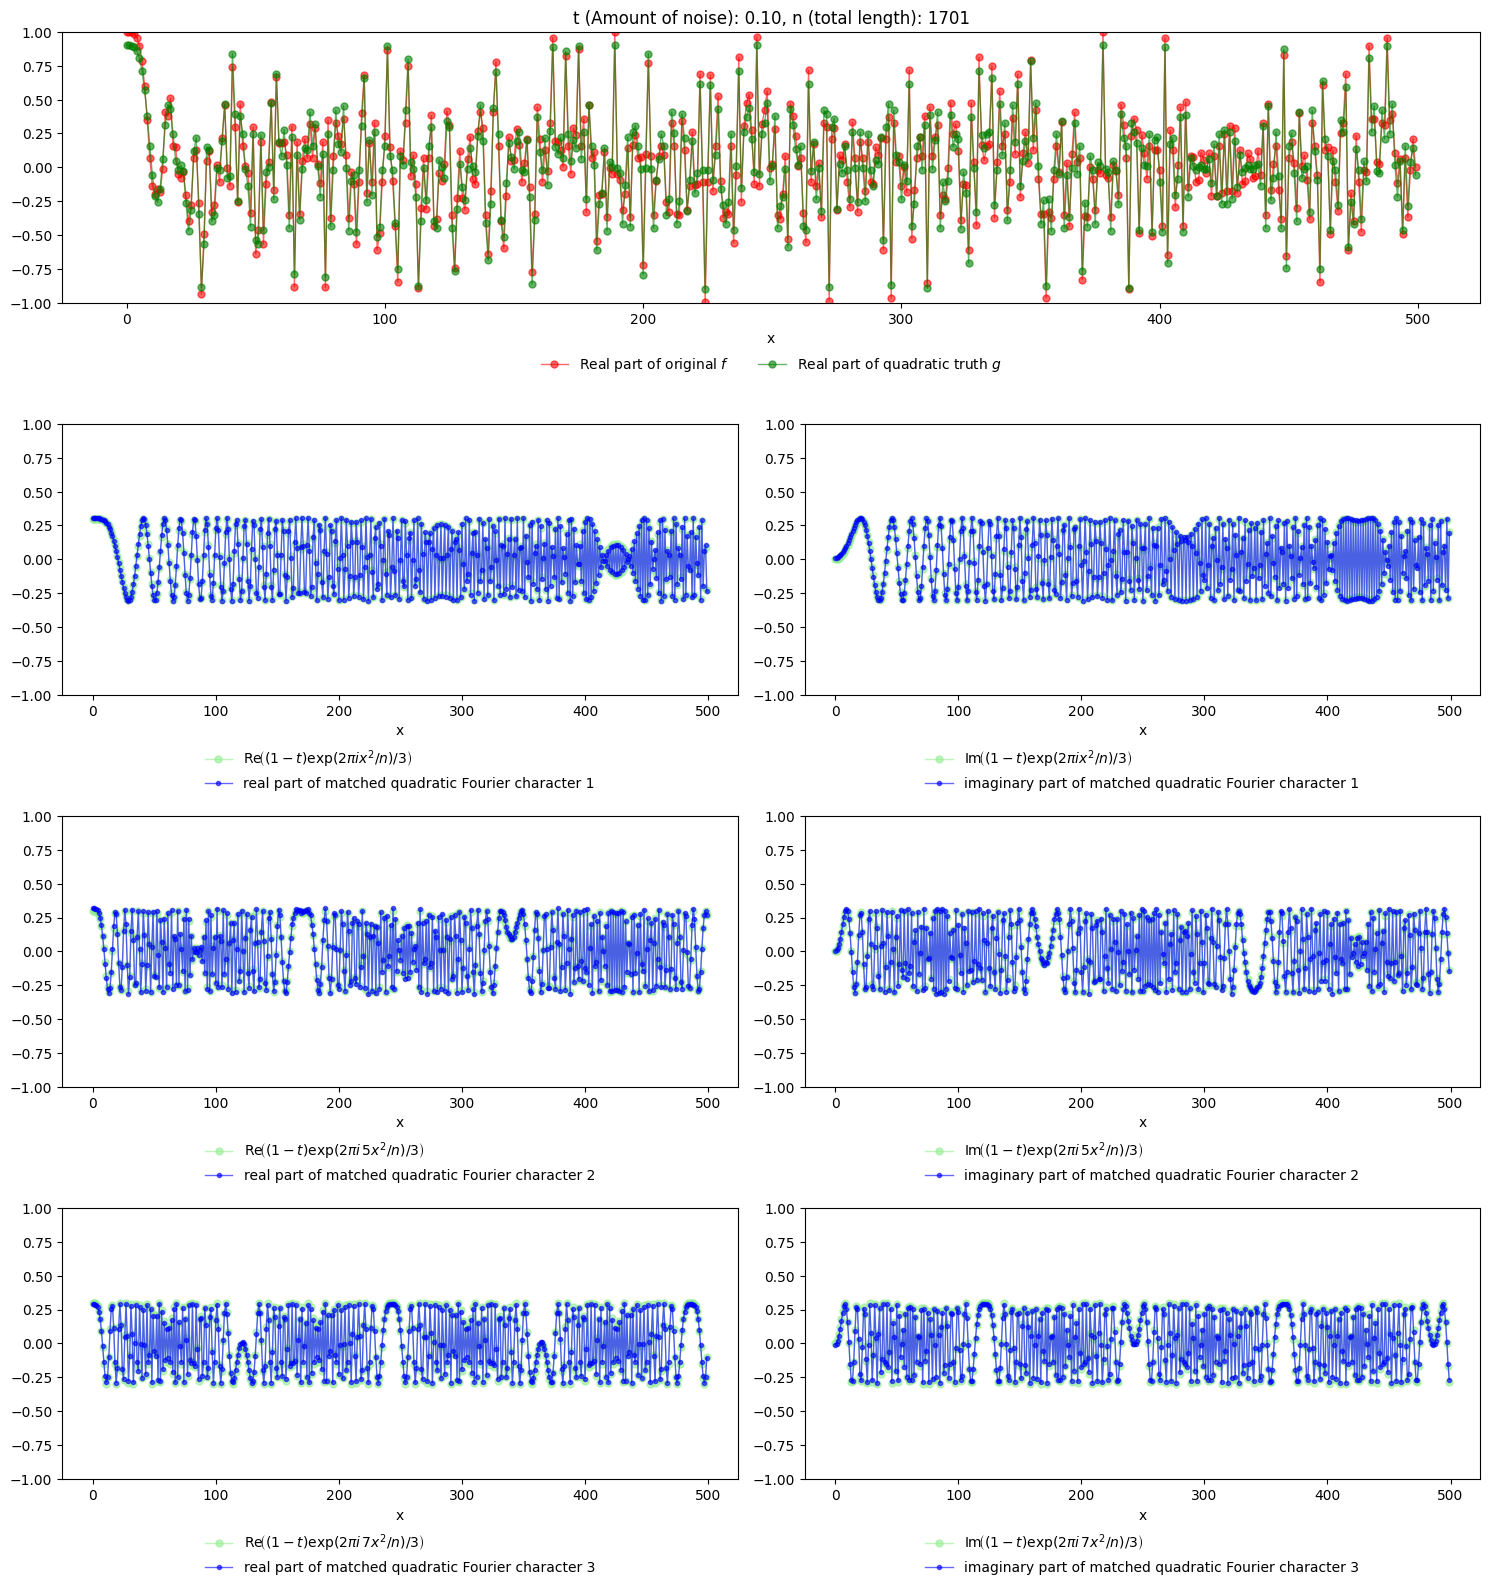

In [10]:
import itertools
import numpy as np
import matplotlib.pyplot as plt

number_of_first_elems_to_plot = 500

v_1 = eichars[:, -1]
coeff_proj_1 = np.mean(f * v_1.conjugate())

v_2 = eichars[:, -2]
coeff_proj_2 = np.mean(f * v_2.conjugate())

v_3 = eichars[:, -3]
coeff_proj_3 = np.mean(f * v_3.conjugate())

# Restrict to plotting window
x_plot = x[:number_of_first_elems_to_plot]

# Target ("green") complex curves
target_1_complex = (1 - t) * np.exp(2 * np.pi * 1j * x_plot**2 / n) / 3
target_2_complex = (1 - t) * np.exp(2 * np.pi * 5 * 1j * x_plot**2 / n) / 3
target_3_complex = (1 - t) * np.exp(2 * np.pi * 7 * 1j * x_plot**2 / n) / 3

targets_complex = [target_1_complex, target_2_complex, target_3_complex]

# Recovered ("blue") complex curves
blue_1_complex = coeff_proj_1 * v_1[:number_of_first_elems_to_plot]
blue_2_complex = coeff_proj_2 * v_2[:number_of_first_elems_to_plot]
blue_3_complex = coeff_proj_3 * v_3[:number_of_first_elems_to_plot]

blues_complex = [blue_1_complex, blue_2_complex, blue_3_complex]

# --- L^2 (squared) error comparison over all 3! possible assignments ---
# Match using the full complex-valued curves

best_perm = None
best_err = np.inf

for perm in itertools.permutations(range(3)):
    total_err = sum(
        np.sum(np.abs(blues_complex[perm[i]] - targets_complex[i])**2)
        for i in range(3)
    )
    if total_err < best_err:
        best_err = total_err
        best_perm = perm

# Reorder blues according to best assignment
matched_blues_complex = [blues_complex[best_perm[i]] for i in range(3)]

# Labels
target_labels_real = [
    r'$\mathrm{Re}\!\left((1-t)\exp(2\pi i x^2/n)/3\right)$',
    r'$\mathrm{Re}\!\left((1-t)\exp(2\pi i\,5x^2/n)/3\right)$',
    r'$\mathrm{Re}\!\left((1-t)\exp(2\pi i\,7x^2/n)/3\right)$',
]

target_labels_imag = [
    r'$\mathrm{Im}\!\left((1-t)\exp(2\pi i x^2/n)/3\right)$',
    r'$\mathrm{Im}\!\left((1-t)\exp(2\pi i\,5x^2/n)/3\right)$',
    r'$\mathrm{Im}\!\left((1-t)\exp(2\pi i\,7x^2/n)/3\right)$',
]

blue_labels_real = [
    r"real part of matched quadratic Fourier character 1",
    r"real part of matched quadratic Fourier character 2",
    r"real part of matched quadratic Fourier character 3",
]

blue_labels_imag = [
    r"imaginary part of matched quadratic Fourier character 1",
    r"imaginary part of matched quadratic Fourier character 2",
    r"imaginary part of matched quadratic Fourier character 3",
]

# --- Plotting ---

# 4 rows x 2 columns:
# top row spans both columns,
# then 3 rows of 2 plots each
fig = plt.figure(figsize=(15, 16))
gs = fig.add_gridspec(4, 2, height_ratios=[1, 1, 1, 1], width_ratios=[1, 1])

# Top plot
ax_top = fig.add_subplot(gs[0, :])
ax_top.plot(
    x_plot,
    np.real(f[:number_of_first_elems_to_plot]),
    linestyle="-",
    color="red",
    marker="o",
    markersize=5,
    linewidth=1,
    alpha=0.6,
    label=r"Real part of original $f$",
)
ax_top.plot(
    x_plot,
    np.real((1 - t) * g[:number_of_first_elems_to_plot] / 3),
    linestyle="-",
    color="green",
    marker="o",
    markersize=5,
    linewidth=1,
    alpha=0.6,
    label=r"Real part of quadratic truth $g$",
)
ax_top.set_xlabel("x")
ax_top.set_title(f"t (Amount of noise): {t:.2f}, n (total length): {n}")
ax_top.set_ylim(-1, 1)
ax_top.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2, frameon=False)

# Bottom 3x2 comparison plots
for i in range(3):
    target = targets_complex[i]
    blue = matched_blues_complex[i]

    # Left: real parts
    ax_real = fig.add_subplot(gs[i + 1, 0])
    ax_real.plot(
        x_plot,
        np.real(target),
        linestyle="-",
        color="lightgreen",
        marker="o",
        markersize=5,
        linewidth=1,
        alpha=0.6,
        label=target_labels_real[i],
    )
    ax_real.plot(
        x_plot,
        np.real(blue),
        linestyle="-",
        color="blue",
        marker="o",
        markersize=3,
        linewidth=1,
        alpha=0.6,
        label=blue_labels_real[i],
    )
    ax_real.set_xlabel("x")
    ax_real.set_ylim(-1, 1)
    ax_real.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=1, frameon=False)

    # Right: imaginary parts
    ax_imag = fig.add_subplot(gs[i + 1, 1])
    ax_imag.plot(
        x_plot,
        np.imag(target),
        linestyle="-",
        color="lightgreen",
        marker="o",
        markersize=5,
        linewidth=1,
        alpha=0.6,
        label=target_labels_imag[i],
    )
    ax_imag.plot(
        x_plot,
        np.imag(blue),
        linestyle="-",
        color="blue",
        marker="o",
        markersize=3,
        linewidth=1,
        alpha=0.6,
        label=blue_labels_imag[i],
    )
    ax_imag.set_xlabel("x")
    ax_imag.set_ylim(-1, 1)
    ax_imag.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=1, frameon=False)

fig.tight_layout()
plt.show()

## **Example**: locating quadratic behaviour in data analysis

The next example shows how ``hofa.char.spechoft`` can locate quadratic behaviour spatially, not only if it is given as a superposition of quadratic (or higher-order) waves.

### Problem statement

Let $n=1701$, $m=500$, and let us define $f:\{0,\ldots,n-1\}\to \mathbb{C}$ as follows:

$$
f(x) =
     \begin{cases}
       \exp(2\pi i x^2/n) & \text{if }x\le m\\
       \exp(10\pi i x^2/n) & \text{if }x> m.
     \end{cases}
$$

In [11]:
n = 1701
m = 500

x = np.arange(n)
f = np.exp(2 * np.pi * 1j * x**2 / n)
f[m:] = np.exp(2 * np.pi * 5 * 1j * x**2 / n)[m:]

### Strategy

We would like to isolate as much as we can the two components of this function.

To do so, we apply ``hofa.char.spechoft``. This time, for illustration purposes, we add a callback function to print the advances in the iterations.

In [12]:
rnd_sep_result = char.spechoft(f , rng=28, callback = char.PrintRandomizedSearchCallback())

eichars = rnd_sep_result.higher_order_char

Total number of iterations 1, iterative search = True, eig vals found = 2, target num eig vals = 2                                                                                     


### Results

We can already see from the message above that ``hofa.char.spechoft`` was able to correctly discover that there are two very different components hiding in $f$. First, let us print the absolute value of the higher-order characters found. Note that it clearly separates the two quadratic components.

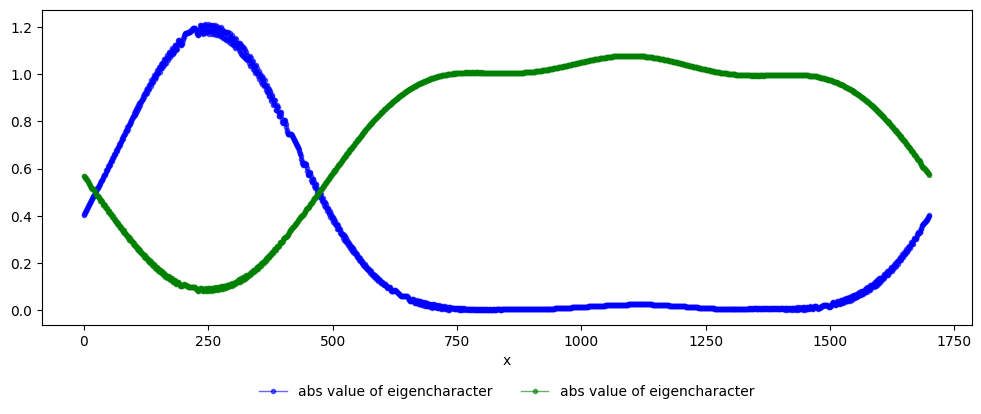

In [13]:
fig, ax = plt.subplots(figsize=(12, 5))

colors = ['blue', 'green', 'yellow', 'red']

for i in range(2):
    # Plot recovered function in blue
    v = rnd_sep_result.higher_order_char[...,i]
    coeff_proj = np.mean(f*v.conjugate())
    ax.plot(x, np.abs(coeff_proj*v), linestyle='-', color=colors[i], marker='o', markersize=3, linewidth=1, alpha=0.6, label='abs value of eigencharacter')

# Customize the plot
ax.set_xlabel("x")
#ax.set_ylim(-1,1)

# Legend below the plot
fig.subplots_adjust(bottom=0.25)  # Adjust layout to fit legend below
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2, frameon=False)

# Show the plot
plt.show()

Let us plot below the different components together with the ones found by the spectral higher-order Fourier transform.

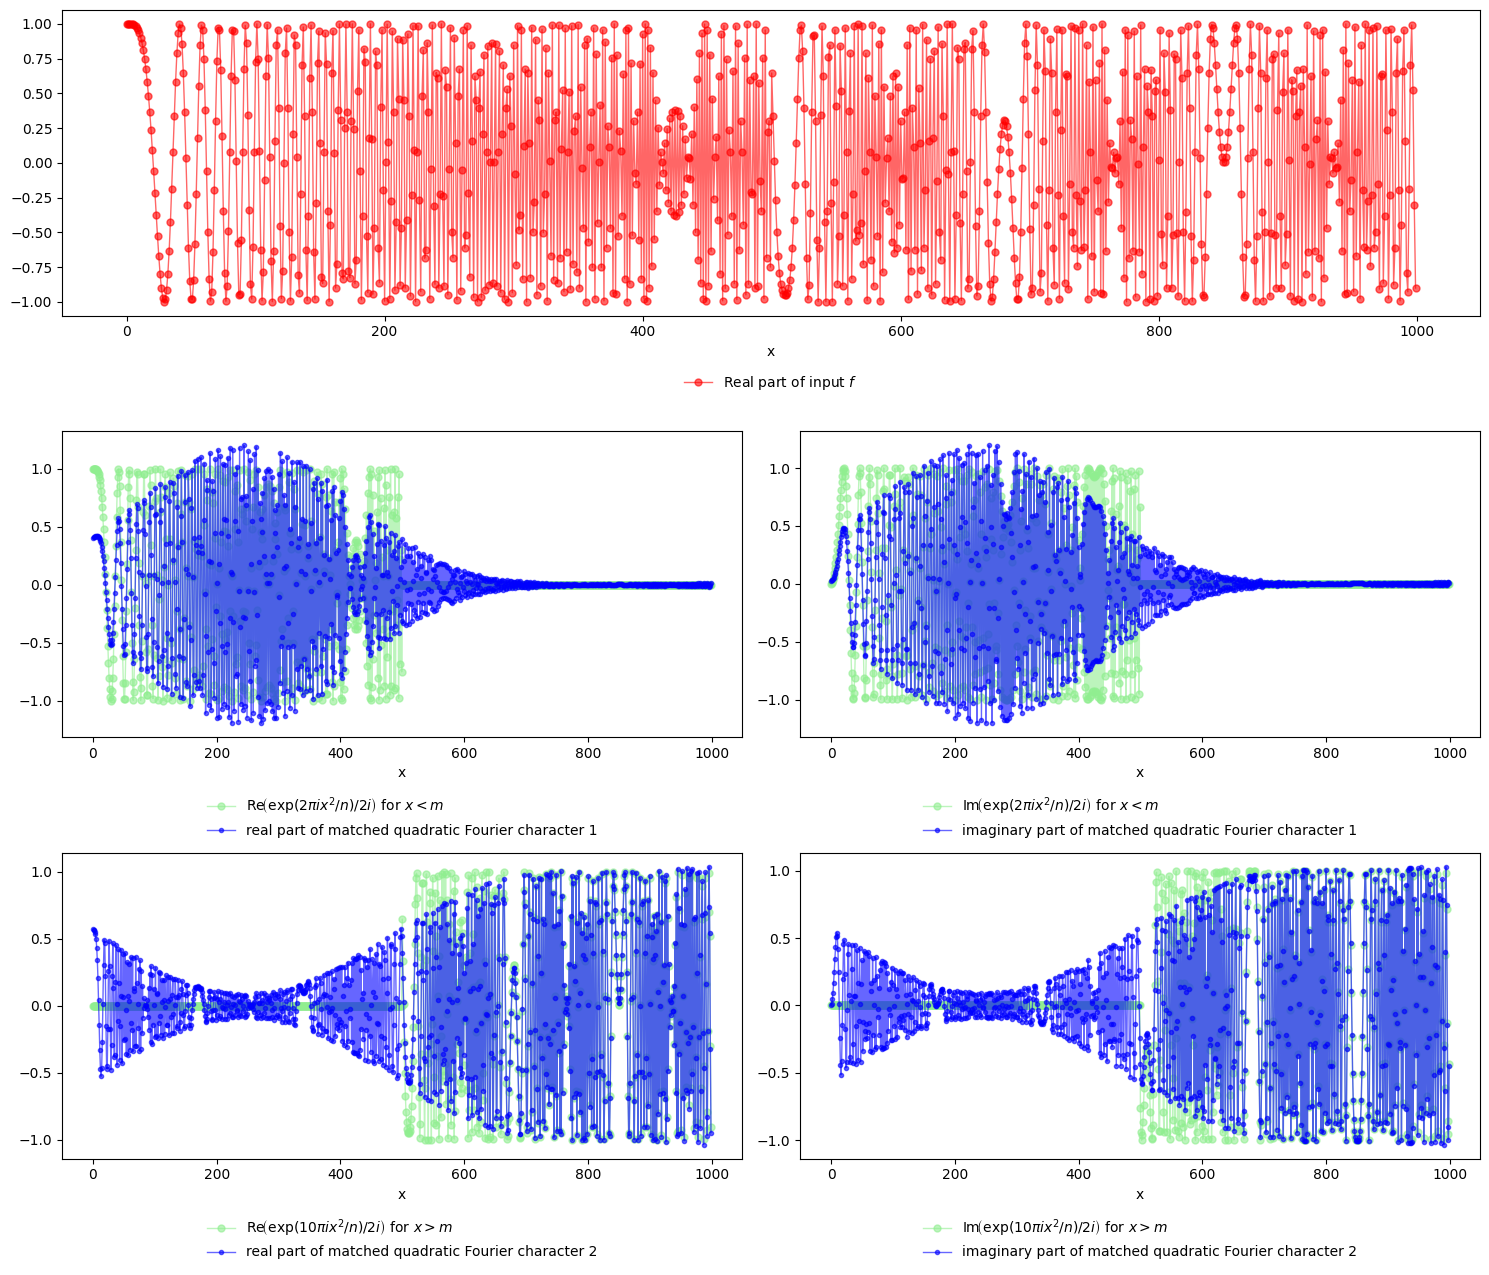

In [14]:
import itertools
import numpy as np
import matplotlib.pyplot as plt

number_of_first_elems_to_plot = 1000

v_1 = eichars[:, -1]
coeff_proj_1 = np.mean(f * v_1.conjugate())

v_2 = eichars[:, -2]
coeff_proj_2 = np.mean(f * v_2.conjugate())

# Restrict to plotting window
x_plot = x[:number_of_first_elems_to_plot]

# Target ("green") complex curves
target_1_complex = np.zeros_like(x_plot, dtype=complex)
target_1_complex[:m] = np.exp(2 * np.pi * 1j * x_plot**2 / n)[:m]

target_2_complex = np.zeros_like(x_plot, dtype=complex)
target_2_complex[m:] = np.exp(10 * np.pi * 1j * x_plot**2 / n)[m:]

targets_complex = [target_1_complex, target_2_complex]

# Recovered ("blue") complex curves
blue_1_complex = coeff_proj_1 * v_1[:number_of_first_elems_to_plot]
blue_2_complex = coeff_proj_2 * v_2[:number_of_first_elems_to_plot]

blues_complex = [blue_1_complex, blue_2_complex]

# --- L^2 (squared) error comparison over all possible assignments ---

best_perm = None
best_err = np.inf

for perm in itertools.permutations(range(2)):
    total_err = sum(
        np.sum(np.abs(blues_complex[perm[i]] - targets_complex[i])**2)
        for i in range(2)
    )
    if total_err < best_err:
        best_err = total_err
        best_perm = perm

# Reorder blues according to best assignment
matched_blues_complex = [blues_complex[best_perm[i]] for i in range(2)]

# Labels
target_labels_real = [
    r'$\mathrm{Re}\!\left(\exp(2\pi i x^2/n)/2i\right)$ for $x< m$',
    r'$\mathrm{Re}\!\left(\exp(10\pi ix^2/n)/2i\right)$ for $x> m$',
]

target_labels_imag = [
    r'$\mathrm{Im}\!\left(\exp(2\pi i x^2/n)/2i\right)$ for $x< m$',
    r'$\mathrm{Im}\!\left(\exp(10\pi ix^2/n)/2i\right)$ for $x> m$',
]

blue_labels_real = [
    r"real part of matched quadratic Fourier character 1",
    r"real part of matched quadratic Fourier character 2",
]

blue_labels_imag = [
    r"imaginary part of matched quadratic Fourier character 1",
    r"imaginary part of matched quadratic Fourier character 2",
]

# --- Plotting ---

fig = plt.figure(figsize=(15, 16))
gs = fig.add_gridspec(4, 2, height_ratios=[1, 1, 1, 1], width_ratios=[1, 1])

# Top plot
ax_top = fig.add_subplot(gs[0, :])
ax_top.plot(
    x_plot,
    np.real(f[:number_of_first_elems_to_plot]),
    linestyle="-",
    color="red",
    marker="o",
    markersize=5,
    linewidth=1,
    alpha=0.6,
    label=r"Real part of input $f$",
)
ax_top.set_xlabel("x")
ax_top.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2, frameon=False)

# Bottom 3x2 comparison plots
for i in range(2):
    target = targets_complex[i]
    blue = matched_blues_complex[i]

    # Left: real parts
    ax_real = fig.add_subplot(gs[i + 1, 0])
    ax_real.plot(
        x_plot,
        np.real(target),
        linestyle="-",
        color="lightgreen",
        marker="o",
        markersize=5,
        linewidth=1,
        alpha=0.6,
        label=target_labels_real[i],
    )
    ax_real.plot(
        x_plot,
        np.real(blue),
        linestyle="-",
        color="blue",
        marker="o",
        markersize=3,
        linewidth=1,
        alpha=0.6,
        label=blue_labels_real[i],
    )
    ax_real.set_xlabel("x")
    ax_real.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=1, frameon=False)

    # Right: imaginary parts
    ax_imag = fig.add_subplot(gs[i + 1, 1])
    ax_imag.plot(
        x_plot,
        np.imag(target),
        linestyle="-",
        color="lightgreen",
        marker="o",
        markersize=5,
        linewidth=1,
        alpha=0.6,
        label=target_labels_imag[i],
    )
    ax_imag.plot(
        x_plot,
        np.imag(blue),
        linestyle="-",
        color="blue",
        marker="o",
        markersize=3,
        linewidth=1,
        alpha=0.6,
        label=blue_labels_imag[i],
    )
    ax_imag.set_xlabel("x")
    ax_imag.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=1, frameon=False)

fig.tight_layout()
plt.show()

### Theoretical justification

Why is the method ``hofa.char.spechoft`` finding this spatial behaviour? The answer lies in the definition of what a quadratic Fourier character is. Recall from [the U3-norm case in the Conceptual background](concept-background-u3-case) that we defined quadratic Fourier characters as functions such that their multiplicative derivatives are (essentially) the sum of _few_ classical Fourier characters.

The function $f$ can be written as follows:

$$ f(x) = \exp(2\pi i x^2/n) 1_{[0,m]}(x)+ \exp(10\pi i x^2/n) 1_{(m,n)}(x) $$

where $1_A$ denotes the indicator function of a subset $A$ of $\{0,\ldots,n-1\}$ (that is, $1_A(x)$ equals 1 if $x\in A$ and 0 otherwise). In this case, $A$ is either $[0,m]=\{x\in \{0,\ldots,n-1\}: x\le m\}$ or $(m,n)=\{x\in \{0,\ldots,n-1\}: x> m\}$.

Recall from the [Important observation](concept-background-important-obs-quad-char) that a quadratic character **times** a function which is the sum of **few** Fourier characters **is also a quadratic character**. In this case, both $1_{[0,m]}(x)$ and $1_{(m,n)}(x)$ are not exactly the sum of **few** classical Fourier characters, but it is true that they can be **approximated very well** by the sum of **few** classical Fourier characters. Hence, under the lens of the function ``hofa.char.spechoft``, both $\exp(2\pi i x^2/n) 1_{[0,m]}(x)$ and $ \exp(10\pi i x^2/n) 1_{(m,n)}(x) $ are **approximately two distinct quadratic characters** and their sum $f$ is simply that: their sum! This is the reason why ``hofa.char.spechoft`` finds approximations of $\exp(2\pi i x^2/n) 1_{[0,m]}(x)$ and $ \exp(10\pi i x^2/n) 1_{(m,n)}(x) $.